In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/ecommerce_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [3]:
df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)

Product_Category
Electronics      10481897.65
Home & Garden     4023903.94
Sports            3205086.99
Fashion           1577035.70
Toys              1014237.53
Beauty             694437.02
Food               422054.65
Books              360399.11
Name: Total_Amount, dtype: float64

In [4]:
category_revenue = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False).reset_index()
category_revenue

,Product_Category,Total_Amount
0,Electronics,10481897.65
1,Home & Garden,4023903.94
2,Sports,3205086.99
3,Fashion,1577035.70
4,Toys,1014237.53
5,Beauty,694437.02
6,Food,422054.65
7,Books,360399.11


In [5]:
category_revenue.to_csv('../data/processed/category_revenue.csv', index=False)

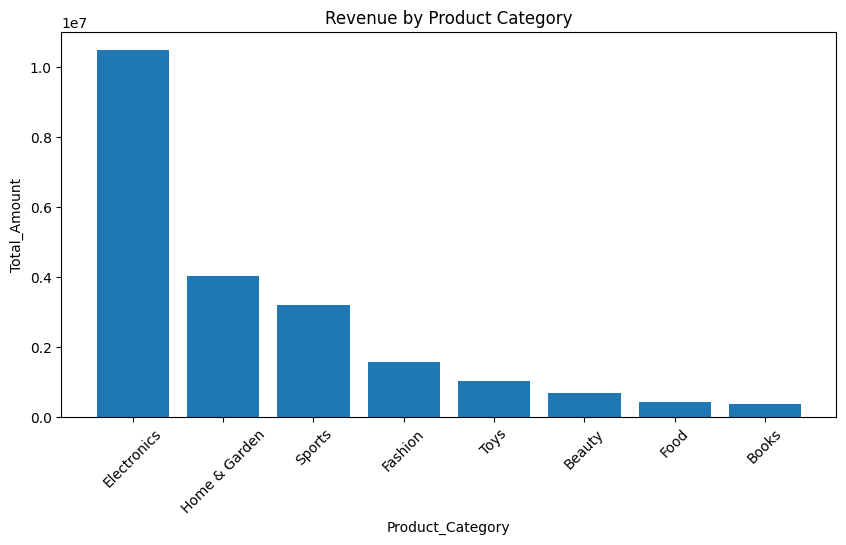

In [6]:
plt.figure(figsize=(10,5))

plt.bar(category_revenue['Product_Category'], category_revenue['Total_Amount'])
plt.xticks(rotation=45)
plt.xlabel("Product_Category")
plt.ylabel("Total_Amount")
plt.title("Revenue by Product Category")

plt.show()

#### Revenue by Product Category

#### Objective
The objective of this analysis was to identify which product categories generate the highest revenue for the business.

#### Methodology

Total revenue was aggregated by product category using the Total_Amount variable.

#### Findings
Category	                Revenue
Electronics	          10,481,897
Home & Garden	           4,023,904
Sports	              3,205,087
Fashion	              1,577,036
Toys	                   1,014,238
Beauty	               694,437
Food	                    422,055
Books	                    360,399

#### Key Insights
- Electronics is the highest revenue-generating category.
- Electronics contributes approximately 48% of total revenue.
- Home & Garden and Sports are the second and third strongest categories.
- Books and Food generate the lowest revenue among all categories.
- Business Recommendation

#### The business
should prioritize marketing campaigns and inventory management for the Electronics category because it represents the largest share of total revenue.

Additionally, further investigation should be conducted to determine whether low-performing categories such as Books and Food require strategic improvements or serve niche customer segments.


In [7]:
df['Product_Category'].value_counts()

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64

In [8]:
df.groupby('Product_Category')['Total_Amount'].mean().sort_values(ascending=False)

Product_Category
Electronics      5053.952580
Home & Garden    1953.351427
Sports           1425.750440
Fashion           767.040710
Toys              485.281115
Beauty            313.940787
Food              200.691702
Books             163.372217
Name: Total_Amount, dtype: float64

#### Order Volume vs Revenue Analysis

#### Objective
To determine whether the high revenue generated by the Electronics category is driven by a larger number of transactions or by higher-value purchases.

#### Findings
The transaction count across product categories is relatively balanced, ranging between approximately 2,000 and 2,250 orders per category.

Despite having a similar number of transactions, Electronics generates significantly more revenue than all other categories.

Further analysis of average order value reveals that:

Electronics: 5,053
Home & Garden: 1,953
Sports: 1,426
Books: 163

#### Key Insight
The Electronics category achieves the highest revenue primarily because customers spend considerably more per transaction.

Revenue leadership is driven by transaction value rather than transaction volume.

#### Business Recommendation
The company should prioritize customer retention and premium-product marketing strategies within the Electronics category, as small increases in Electronics sales can have a disproportionately large impact on total revenue.

In [9]:
city_revenue = (
    df.groupby('City')['Total_Amount'].sum()
    .sort_values(ascending=False)
    .reset_index()
)

city_revenue

,City,Total_Amount
0,Istanbul,5646595.78
1,Ankara,3052443.10
2,Izmir,2651743.92
3,Bursa,2317028.10
4,Antalya,1661594.15
5,Gaziantep,1573422.25
6,Adana,1512320.19
7,Konya,1363152.80
8,Kayseri,1091658.53
9,Eskisehir,909093.77


### Revenue by City

#### Objective
To identify which cities generate the highest revenue and contribute most to overall business performance.

#### Findings
The revenue distribution is concentrated in a small number of cities.

Top revenue-generating cities:

City	      Revenue
Istanbul	5.65M
Ankara	        3.05M
Izmir	        2.65M


#### Key Insight
Istanbul is the most valuable market, generating approximately 26% of total company revenue.

The top three cities contribute a significant portion of overall sales, indicating that business performance is highly concentrated geographically.

#### Business Recommendation
Marketing campaigns, inventory allocation, and customer retention strategies should prioritize Istanbul due to its substantial contribution to total revenue.

In [10]:
df.groupby('City')['Total_Amount'].mean().sort_values(ascending=False)

City
Bursa        1346.326612
Antalya      1333.542657
Gaziantep    1330.027261
Eskisehir    1287.668229
Kayseri      1282.794982
Istanbul     1282.734162
Izmir        1279.799189
Ankara       1260.298555
Konya        1217.100714
Adana        1140.512964
Name: Total_Amount, dtype: float64

#### Revenue vs Average Order Value by City

#### Objective
To determine whether high-revenue cities generate more revenue because of higher transaction volume or because customers spend more per order.

#### Findings
While Istanbul generates the highest total revenue, it does not have the highest average order value.


Average order value rankings show:

City	Average Order Value
Bursa	        1346
Antalya	        1334
Gaziantep	1330

#### Key Insight
Istanbul's revenue leadership is primarily driven by transaction volume rather than customer spending per transaction.

Bursa demonstrates the highest average order value, indicating that customers in Bursa spend more per purchase on average.

#### Business Recommendation
Different strategies should be applied across cities:

- Istanbul: focus on customer acquisition and retention due to high transaction volume.

- Bursa: focus on premium product offerings and upselling opportunities due to higher spending per transaction.

In [11]:
df.groupby('Is_Returning_Customer')['Total_Amount'].agg(
    ['count', 'mean', 'sum']
)

,count,mean,sum
Is_Returning_Customer,,,
False,2010,1287.727428,2588332.13
True,15039,1276.063599,19190720.46


In [ ]:
df.groupby('Gender')['Total_Amount'].agg(
    ['count','mean','sum']
).sort_values('sum', ascending=False)

,count,mean,sum
Gender,,,
Female,8613,1281.549356,11037984.60
Male,8176,1265.066744,10343185.70
Other,260,1530.316500,397882.29


In [ ]:
df.groupby('Device_Type')['Total_Amount'].agg(
    ['count','mean','sum']
).sort_values('sum', ascending=False)

,count,mean,sum
Device_Type,,,
Mobile,9543,1260.472104,12028685.29
Desktop,5845,1310.767677,7661437.07
Tablet,1661,1257.634094,2088930.23


In [ ]:
plt.figure(figsize=(10,5))

plt.bar(category_revenue['Device_Type'], category_revenue['Total_Amount'])
plt.xticks(rotation=45)
plt.xlabel("Device_Type")
plt.ylabel("Total_Amount")
plt.title("Revenue by Device Type")

plt.show()

#### Revenue by Device Type

#### Objective
To understand how different device types contribute to business revenue.

#### Findings
- Mobile devices generate the highest total revenue.
- Desktop users exhibit the highest average order value.
- Tablet users contribute the smallest share of revenue.


#### Key Insight
Mobile dominates revenue because of transaction volume, while Desktop users spend slightly more per transaction.


#### Business Recommendation
The business should continue optimizing the mobile shopping experience due to its large revenue contribution, while also investigating opportunities to increase traffic to desktop channels where customer spending per order is higher.